# 03. NLP-подход по answer + description

Третий текстовый эксперимент: лемматизация, TF-IDF по `description`, char n-gram TF-IDF по `answer` и логические признаки ребусов.

In [1]:
from pathlib import Path
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import pymorphy3

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split

## Загрузка и предобработка

In [2]:
DATA_PATH = Path("../data.csv")
df = pd.read_csv(DATA_PATH)

morph = pymorphy3.MorphAnalyzer()

def clean_and_lemmatize(text):
    if pd.isna(text): return "пусто"
    text = str(text).lower()
    words = re.findall(r'[а-яёa-z]+', text)
    if not words: return "пусто"
    res = [morph.parse(w)[0].normal_form for w in words]
    return " ".join(res)

df["lemma_description"] = df["description"].apply(clean_and_lemmatize)
df["lemma_answer"] = df["answer"].apply(lambda x: clean_and_lemmatize(str(x).split('|')[0]))
df.head()

,id,answer,description,date_posted,img_url,started,solved,users_with_hints,total_hints,solve_rate,hint_usage,avg_hints,difficulty,lemma_description,lemma_answer
0,1,брауни,Коричневая английская Е (читается как и) = Bro...,2025-06-01,/daily-rebuses/1_v1.jpg,454,219,110,179,0.4824,0.2423,0.3943,0.4303,коричневый английский быть читаться как и brow...,брауни
1,2,tralalelo tralala|тралалело тралала|тралалеро ...,Один из самых известных героев мема BrainRot -...,2025-06-02,/daily-rebuses/2.jpg,339,162,65,90,0.4779,0.1917,0.2655,0.4010,один из самый известный герой мем brainrot аку...,tralalelo tralala
2,3,свитер|свита,Свитер или Свита. Сладкая буква R. (sweet R). ...,2025-06-03,/daily-rebuses/3_v1.jpg,276,134,38,56,0.4855,0.1377,0.2029,0.3736,свитер или свита сладкий буква r sweet r r чит...,свитер
3,4,подоконник,Под О Конь и К,2025-06-04,/daily-rebuses/4.jpg,255,183,19,28,0.7176,0.0745,0.1098,0.2045,под о конь и к,подоконник
4,5,редактор,Красный актер = Red Actor,2025-06-05,/daily-rebuses/5_v1.jpg,311,200,96,158,0.6431,0.3087,0.5080,0.3675,красный актёр red actor,редактор


## Извлечение логических признаков ребуса

In [3]:
def extract_rebus_logic(row):
    desc = str(row["description"]).lower()
    ans = str(row["answer"]).lower().split('|')[0]
    
    pos_prepositions = [" в ", " на ", " под ", " над ", " за ", " перед ", " из "]
    rebus_terms = ["запятая", "перевернутый", "вверх ногами", "зачеркнуть", "буква", "цифра"]
    
    return pd.Series({
        "comma_count": desc.count(",") + desc.count("'"),
        "desc_len": len(desc),
        "ans_len": len(ans.replace(" ", "")),
        "has_pos_prep": int(any(p in desc for p in pos_prepositions)),
        "has_rebus_terms": int(any(t in desc for t in rebus_terms)),
        "is_multi_word_ans": int(" " in ans.strip()),
        "variant_count": str(row["answer"]).count('|') + 1
    })

rebus_features = df.apply(extract_rebus_logic, axis=1)
X_full = pd.concat([df[["lemma_description", "lemma_answer"]], rebus_features], axis=1)
y = df["difficulty"]

## Создание пайплайна

In [4]:
numeric_features = rebus_features.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("desc_tfidf", TfidfVectorizer(max_features=500), "lemma_description"),
        ("ans_tfidf", TfidfVectorizer(analyzer="char", ngram_range=(2, 4), max_features=300), "lemma_answer"),
        ("num", StandardScaler(), numeric_features)
    ]
)

def create_pipeline(model):
    return Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", model)
    ])

X_train, X_test, y_train, y_test = train_test_split(X_full, y, test_size=0.2, random_state=42)

In [5]:
models = {
    "ridge": create_pipeline(Ridge(alpha=1.0)),
    "lasso": create_pipeline(Lasso(alpha=0.001, max_iter=10000)),
    "gbr": create_pipeline(GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)),
    "rf": create_pipeline(RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42))
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    scores = cross_validate(model, X_full, y, cv=cv, scoring={"mae": "neg_mean_absolute_error", "r2": "r2"})
    results.append({
        "model": name,
        "mae_mean": -scores["test_mae"].mean(),
        "r2_mean": scores["test_r2"].mean()
    })

pd.DataFrame(results).sort_values("mae_mean")

,model,mae_mean,r2_mean
0,ridge,0.081478,0.082087
3,rf,0.082417,0.087977
1,lasso,0.082709,0.092570
2,gbr,0.085389,0.012073


## Визуализация лучшей модели

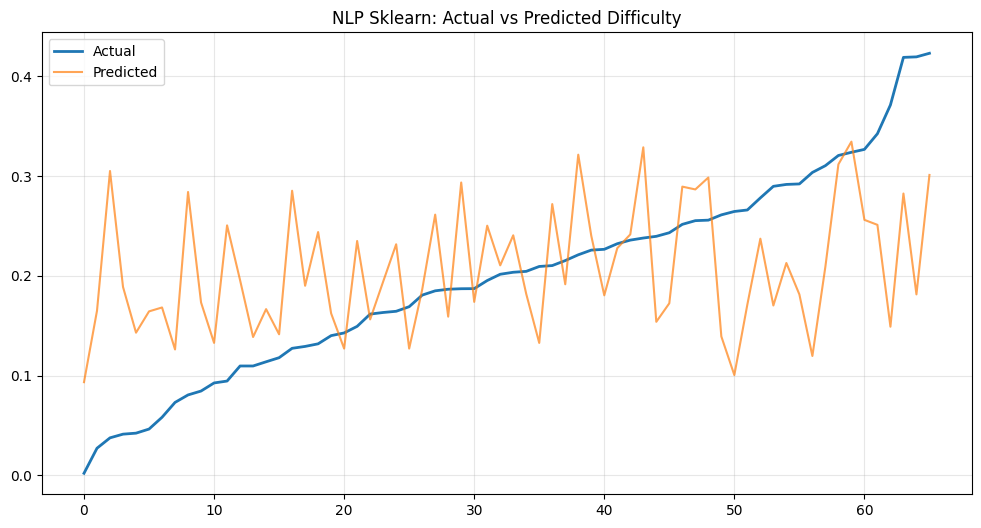

In [6]:
# Обучаем Ridge как базовую стабильную модель
best_model = create_pipeline(Ridge(alpha=1.0))
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

plot_df = pd.DataFrame({"Actual": y_test, "Predicted": y_pred}).sort_values("Actual").reset_index(drop=True)
plt.figure(figsize=(12, 6))
plt.plot(plot_df["Actual"].values, label="Actual", linewidth=2)
plt.plot(plot_df["Predicted"].values, label="Predicted", alpha=0.7)
plt.title("NLP Sklearn: Actual vs Predicted Difficulty")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()